In [6]:
import tensorflow as tf
import numpy as np
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt

In [30]:
TRAIN_DIR = "/kaggle/input/datasets/saifurrahmanmamun/cifar-10/train"
VAL_DIR   = "/kaggle/input/datasets/saifurrahmanmamun/cifar-10/val"
TEST_DIR  = "/kaggle/input/datasets/saifurrahmanmamun/cifar-10/test"


train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0.2,    # Automatically reserve 20% of images for testing
    subset="training",       # Tell it to grab the 80% half
    seed=42,                 # Ensures the 80/20 split is identical every time you run it
    image_size=(32, 32),     # CRUCIAL: Force all images to match your Conv2D Input layer shape
    batch_size=32
)
print(train_ds.class_names)

val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    validation_split=0.2,
    subset="validation",     # Tell it to grab the remaining 20% half
    seed=42,
    image_size=(32, 32),
    batch_size=32
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    shuffle=False,
    image_size=(32,32),
    batch_size=32
)
normalization_layer = tf.keras.layers.Rescaling(1./255)
train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))
test_ds = test_ds.map(lambda x, y: (normalization_layer(x), y))

Found 45000 files belonging to 10 classes.
Using 36000 files for training.
['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']
Found 5000 files belonging to 10 classes.
Using 1000 files for validation.
Found 10000 files belonging to 10 classes.


In [19]:
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

In [20]:
model = models.Sequential([
layers.Input(shape=(32, 32, 3)),
layers.Conv2D(32, (3, 3), activation='relu'),
layers.MaxPooling2D((2, 2)),
layers.Conv2D(64, (3, 3), activation='relu'),
layers.MaxPooling2D((2, 2)),
layers.Conv2D(64, (3, 3), activation='relu')
])

In [33]:
model.add(layers.Flatten())
model.add(layers.Dense(256, activation='relu'))
model.add(layers.Dense(128, activation='relu'))
model.add(layers.Dense(10))

In [34]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

history = model.fit(train_ds, epochs=10, 
                    validation_data=val_ds)

Epoch 1/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.8869 - loss: 0.3346 - val_accuracy: 0.6910 - val_loss: 1.3448
Epoch 2/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.9072 - loss: 0.2730 - val_accuracy: 0.6880 - val_loss: 1.2707
Epoch 3/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.9119 - loss: 0.2545 - val_accuracy: 0.6820 - val_loss: 1.4580
Epoch 4/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.9186 - loss: 0.2342 - val_accuracy: 0.7050 - val_loss: 1.3535
Epoch 5/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.9215 - loss: 0.2328 - val_accuracy: 0.6840 - val_loss: 1.4674
Epoch 6/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.9272 - loss: 0.2138 - val_accuracy: 0.6950 - val_loss: 1.4403
Epoch 7/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.9315 - loss: 0.2020 - val_accuracy: 0.6820 - val_loss: 1.5989
Epoch 8/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.9338 - loss: 0.1936 -

In [35]:
test_loss, test_accuracy = model.evaluate(test_ds)

print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.6650 - loss: 1.7436
Test Accuracy: 0.6650000214576721


In [25]:
for images, labels in test_ds.take(1):
    predictions = model.predict(images)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 370ms/step


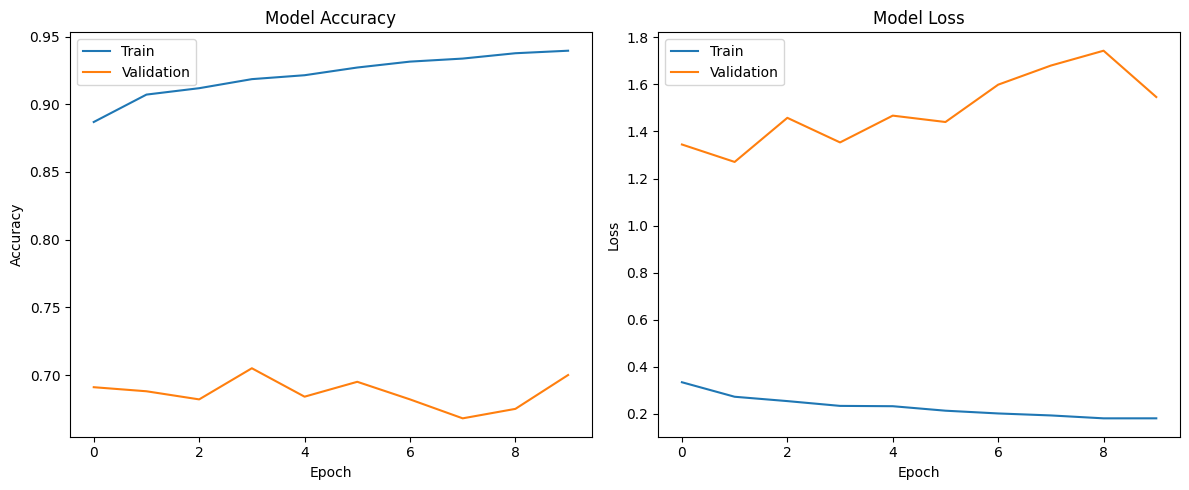

313/313 - 2s - 7ms/step - accuracy: 0.6650 - loss: 1.7436

Test Loss     : 1.7436
Test Accuracy : 66.50%


In [36]:
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

# Test performance
test_loss, test_acc = model.evaluate(test_ds, verbose=2)

print(f"\nTest Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_acc:.2%}")